
# Part 3 — Noise Comparison Experiments

Part 2 studied each noise channel in isolation, one scalar parameter at a time, on a single qubit.
Real experiments vary more than one thing at once: how long a state sits idle (**circuit depth**),
how many qubits are entangled together (**qubit count**), and which physical process is dominant
(**channel**). This notebook adds those two extra axes, using the same Kraus-operator machinery
from Part 2, and produces the three metrics named in the project roadmap: **fidelity**,
**success probability**, and **error rate**.

**Goals**

1. Derive how repeating a noise channel `depth` times composes — the key fact that turns "one
   noisy layer" into a genuine model of accumulating idle-time decoherence.
2. Extend Part 2's single-qubit, single-layer view to many qubits and many layers
   (`src.experiment_utils.apply_noise_layers`).
3. Run a small sweep directly in this notebook (fast, self-contained, verifies the machinery).
4. Load and discuss the full committed sweep (`experiments/results/noise_sweep.csv`, produced by
   `experiments/run_noise_sweep.py` from a checked-in TOML config) for the complete picture.
5. Flag this experiment's limitations honestly, and note what would feed directly into Part 5's
   research question.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import DensityMatrix, Kraus, SuperOp, Statevector, state_fidelity

from src.circuits import add_idle_layers, add_measurements, bell_state, ghz_state
from src.experiment_utils import apply_noise_layers, error_rate, success_probability
from src.noise_models import CHANNEL_KRAUS_BUILDERS, bit_flip_kraus, depolarizing_kraus, amplitude_damping_kraus, single_qubit_noise_model
from src.simulation import sample_counts
from src.visualization import CATEGORICAL_COLORS

%matplotlib inline



## What does "depth" mean for a noise channel?

`src.circuits.add_idle_layers` inserts `barrier + id(all qubits)` blocks, and
`src.noise_models.single_qubit_noise_model` attaches a channel to the `id` gate — so `depth`
layers means the channel is applied **independently, `depth` times in a row**, to each qubit.
Composing a channel with itself is applying its `SuperOp` twice; a natural question is whether
that composition has a closed form in the channel's own parameter, for the specific channels used
here. It does, for three of the five, and it's worth deriving because it's exactly what connects
"depth" back to a physical decay curve.

**Bit flip**, composed $k$ times, is again a bit-flip channel. An $X$ error either lands or
doesn't at each layer; the *net* effect is an $X$ iff an **odd** number of the $k$ independent
flips occurred (since $X^2=I$). For $k$ i.i.d. Bernoulli($p$) trials, the probability of an odd
count follows the standard "random walk on $\mathbb Z_2$" identity:

$$p_k = P(\text{odd number of flips in } k \text{ trials}) = \tfrac12 - \tfrac12(1-2p)^k$$

**Depolarizing**, composed $k$ times, stays depolarizing: since $\mathcal E(\rho)=(1-p)\rho+p\,I/2$
is an affine contraction toward $I/2$, composing it $k$ times contracts by $(1-p)^k$:

$$p_k = 1-(1-p)^k$$

**Amplitude damping**, composed $k$ times, stays amplitude damping with

$$\gamma_k = 1-(1-\gamma)^k$$

— exactly the discrete form of continuous exponential $T_1$ decay: if each layer represents idle
time $\delta t$ with $\gamma = 1-e^{-\delta t/T_1}$, then $\gamma_k = 1-e^{-k\delta t/T_1}$, the
familiar $T_1$ decay law falls straight out of composing independent layers. All three are
verified below via `SuperOp` equality (never by comparing Kraus operators — same non-uniqueness
caveat as Part 2's `docs/interview_questions.md` Q8).


In [2]:

def compose_k_times(kraus_builder, param, k):
    channel = SuperOp(Kraus(kraus_builder(param)))
    composed = channel
    for _ in range(k - 1):
        composed = composed.compose(channel)
    return composed

checks = []
for p in (0.1, 0.3):
    for k in (2, 3, 5):
        p_k = 0.5 - 0.5 * (1 - 2 * p) ** k
        checks.append(("bit_flip", p, k, p_k, np.allclose(
            compose_k_times(bit_flip_kraus, p, k).data,
            SuperOp(Kraus(bit_flip_kraus(p_k))).data,
        )))
        p_k = 1 - (1 - p) ** k
        checks.append(("depolarizing", p, k, p_k, np.allclose(
            compose_k_times(depolarizing_kraus, p, k).data,
            SuperOp(Kraus(depolarizing_kraus(p_k))).data,
        )))
        g_k = 1 - (1 - p) ** k
        checks.append(("amplitude_damping", p, k, g_k, np.allclose(
            compose_k_times(amplitude_damping_kraus, p, k).data,
            SuperOp(Kraus(amplitude_damping_kraus(g_k))).data,
        )))

for name, p, k, p_k, ok in checks:
    print(f"{name:18s} p={p:.1f} k={k}  ->  composed parameter {p_k:.4f}   matches closed form: {ok}")


bit_flip           p=0.1 k=2  ->  composed parameter 0.1800   matches closed form: True
depolarizing       p=0.1 k=2  ->  composed parameter 0.1900   matches closed form: True
amplitude_damping  p=0.1 k=2  ->  composed parameter 0.1900   matches closed form: True
bit_flip           p=0.1 k=3  ->  composed parameter 0.2440   matches closed form: True
depolarizing       p=0.1 k=3  ->  composed parameter 0.2710   matches closed form: True
amplitude_damping  p=0.1 k=3  ->  composed parameter 0.2710   matches closed form: True
bit_flip           p=0.1 k=5  ->  composed parameter 0.3362   matches closed form: True
depolarizing       p=0.1 k=5  ->  composed parameter 0.4095   matches closed form: True
amplitude_damping  p=0.1 k=5  ->  composed parameter 0.4095   matches closed form: True
bit_flip           p=0.3 k=2  ->  composed parameter 0.4200   matches closed form: True
depolarizing       p=0.3 k=2  ->  composed parameter 0.5100   matches closed form: True
amplitude_damping  p=0.3 k=2  ->


## Fidelity vs. depth (small in-notebook sweep)

Using `apply_noise_layers` (which applies a channel independently to every qubit, `num_layers`
times), track Bell-state fidelity as depth grows, for a few channels at a fixed parameter.


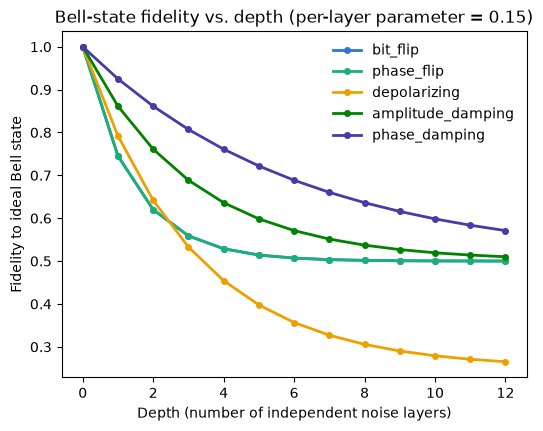

In [3]:

bell_rho_ideal = DensityMatrix(Statevector.from_instruction(bell_state("phi_plus")))
depths = list(range(0, 13))
param = 0.15
channels_to_show = ["bit_flip", "phase_flip", "depolarizing", "amplitude_damping", "phase_damping"]

fig, ax = plt.subplots(figsize=(6, 4.5))
for name, color in zip(channels_to_show, CATEGORICAL_COLORS):
    builder = CHANNEL_KRAUS_BUILDERS[name]
    fidelities = [
        state_fidelity(bell_rho_ideal, apply_noise_layers(bell_rho_ideal, builder, param, d, qubits=[0, 1]))
        for d in depths
    ]
    ax.plot(depths, fidelities, label=name, color=color, linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Depth (number of independent noise layers)")
ax.set_ylabel("Fidelity to ideal Bell state")
ax.set_title(f"Bell-state fidelity vs. depth (per-layer parameter = {param})")
ax.legend(frameon=False)
plt.show()



**Reading the plot.** Depolarizing decays fastest — consistent with Part 2's finding that it's the
only *isotropic* channel, attacking all Bloch directions every layer instead of just some.
Amplitude damping's curve visibly bends back upward at larger depth as the state gets pulled all
the way to its non-unital fixed point $|00\rangle$ (which, note, is itself a **product** state —
so this is also entanglement being destroyed, not just "fidelity to a moving target"). The
bit-flip and phase-flip curves sit exactly on top of each other — not a rendering artifact, but an
exact identity: $|\Phi^+\rangle$ is invariant (up to relabeling) under $H^{\otimes2}$, which
conjugates $X\leftrightarrow Z$, so the two channels give identical fidelity trajectories on this
particular state (verified numerically to machine precision alongside this notebook).



## Fidelity vs. qubit count (GHZ)

Part 1 found that GHZ entanglement is uniquely fragile: losing access to even *one* of $n$ qubits
destroys all coherence among the rest (interview Q6). Here's the noisy-channel analogue: fix a
channel and a per-layer parameter, and see how fidelity degrades as $n$ grows, for one layer of
independent per-qubit noise.


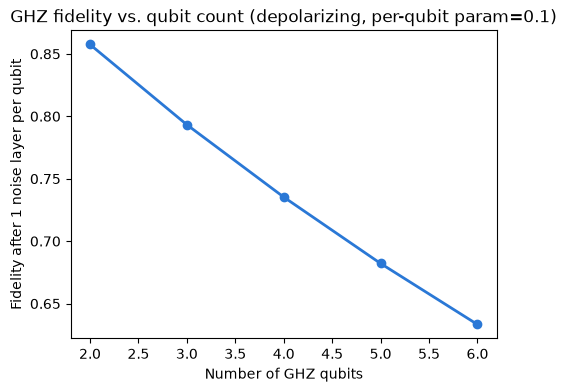

Fidelities: [0.8575 0.7933 0.7353 0.6821 0.6333]
Ratios between consecutive n (roughly constant => roughly exponential in n): [0.9251 0.927  0.9277 0.9284]


In [4]:

qubit_counts = [2, 3, 4, 5, 6]
param = 0.1
channel = "depolarizing"
builder = CHANNEL_KRAUS_BUILDERS[channel]

fidelities_vs_n = []
for n in qubit_counts:
    ideal_rho = DensityMatrix(Statevector.from_instruction(ghz_state(n)))
    noisy_rho = apply_noise_layers(ideal_rho, builder, param, num_layers=1, qubits=list(range(n)))
    fidelities_vs_n.append(state_fidelity(ideal_rho, noisy_rho))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(qubit_counts, fidelities_vs_n, color=CATEGORICAL_COLORS[0], linewidth=2, marker="o", markersize=6)
ax.set_xlabel("Number of GHZ qubits")
ax.set_ylabel("Fidelity after 1 noise layer per qubit")
ax.set_title(f"GHZ fidelity vs. qubit count ({channel}, per-qubit param={param})")
plt.show()

print("Fidelities:", np.round(fidelities_vs_n, 4))
print("Ratios between consecutive n (roughly constant => roughly exponential in n):",
      np.round(np.array(fidelities_vs_n[1:]) / np.array(fidelities_vs_n[:-1]), 4))



Each additional qubit adds one more independent chance for the channel to damage the state, so
fidelity falls off roughly like $(\text{per-qubit survival})^n$ — geometric, not linear, in qubit
count. This is exactly the quantitative version of Part 1's qualitative "GHZ is fragile" finding,
and it directly motivates the Part 5 research question: *which channel's fidelity decays fastest
as a function of qubit count?*



## The full sweep

The cells above ran a small, fast, self-contained sweep to verify the machinery. The full grid —
5 channels x up to 11 parameter values x up to 4 depths x (for GHZ) 5 qubit counts — is run
separately by `experiments/run_noise_sweep.py` from the checked-in
`experiments/configs/noise_sweep.toml`, with fixed seeds so the committed
`experiments/results/noise_sweep.csv` is exactly reproducible. Load it here for the complete
picture.


In [5]:

results = pd.read_csv("../experiments/results/noise_sweep.csv")
print(results.shape)
results.head()


(670, 8)


,circuit,qubit_count,channel,param,depth,fidelity,success_probability,error_rate
0,bell_phi_plus,2,bit_flip,0.0,1,1.00,1.000000,0.000000
1,bell_phi_plus,2,bit_flip,0.1,1,0.82,0.808838,0.191162
2,bell_phi_plus,2,bit_flip,0.2,1,0.68,0.669434,0.330566
3,bell_phi_plus,2,bit_flip,0.3,1,0.58,0.570557,0.429443
4,bell_phi_plus,2,bit_flip,0.4,1,0.52,0.512451,0.487549


In [6]:

# Sanity check baked into the metrics themselves: success_probability + error_rate == 1 always.
assert np.allclose(results["success_probability"] + results["error_rate"], 1.0)
print("success_probability + error_rate == 1 for all", len(results), "rows: confirmed")


success_probability + error_rate == 1 for all 670 rows: confirmed


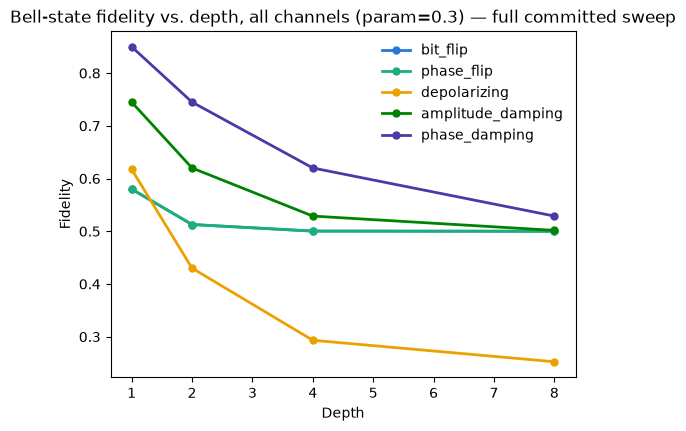

In [7]:

# Bell-state fidelity vs. depth, one line per channel, at a fixed parameter.
subset = results[(results.circuit == "bell_phi_plus") & (results.param == 0.3)].sort_values("depth")

fig, ax = plt.subplots(figsize=(6, 4.5))
for name, color in zip(channels_to_show, CATEGORICAL_COLORS):
    channel_rows = subset[subset.channel == name]
    ax.plot(channel_rows.depth, channel_rows.fidelity, label=name, color=color, linewidth=2, marker="o", markersize=5)

ax.set_xlabel("Depth")
ax.set_ylabel("Fidelity")
ax.set_title("Bell-state fidelity vs. depth, all channels (param=0.3) — full committed sweep")
ax.legend(frameon=False)
plt.show()


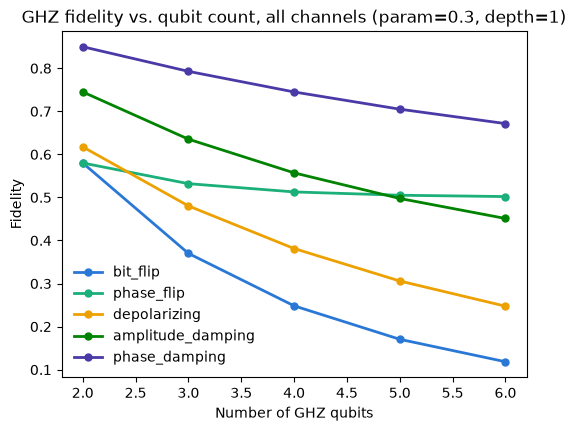

In [8]:

# GHZ fidelity vs. qubit count, all channels, at a fixed parameter and depth=1 --
# the systematic version of the single-channel plot above, and the direct input to Part 5.
subset = results[(results.circuit == "ghz") & (results.param == 0.3) & (results.depth == 1)].sort_values("qubit_count")

fig, ax = plt.subplots(figsize=(6, 4.5))
for name, color in zip(channels_to_show, CATEGORICAL_COLORS):
    channel_rows = subset[subset.channel == name]
    ax.plot(channel_rows.qubit_count, channel_rows.fidelity, label=name, color=color, linewidth=2, marker="o", markersize=5)

ax.set_xlabel("Number of GHZ qubits")
ax.set_ylabel("Fidelity")
ax.set_title("GHZ fidelity vs. qubit count, all channels (param=0.3, depth=1)")
ax.legend(frameon=False)
plt.show()



**Reading this plot.** If one channel's curve visibly separates from the rest as $n$ grows, that's
the beginning of an answer to Part 5's working question (which channel degrades GHZ fidelity
fastest as qubit count increases) — worth checking carefully rather than eyeballing a single seed
before committing to it as a finding.


In [9]:

# Fidelity vs. error rate at the same (channel, param, depth) -- do the two metrics agree on ranking?
bell_fixed_depth = results[(results.circuit == "bell_phi_plus") & (results.depth == 4)]
comparison = bell_fixed_depth.groupby("channel")[["fidelity", "error_rate"]].mean().sort_values("fidelity")
print(comparison)


                   fidelity  error_rate
channel                                
depolarizing       0.364362    0.432928
amplitude_damping  0.576242    0.077659
bit_flip           0.607748    0.400812
phase_flip         0.607748    0.000000
phase_damping      0.615150    0.000000



**Fidelity vs. error rate can disagree**, and it's worth being explicit about why: `error_rate`
only asks "did the measured bitstring fall outside the ideal support?" — a coarse, basis-dependent
yes/no that is completely blind to *how far* a state has drifted within a fixed measurement basis.
`fidelity` is the full quantum-state overlap and can distinguish cases that look identical to
`error_rate`. Concretely: phase flip and phase damping barely move the diagonal populations at all
(Part 2 Q10 — they only ever damage *coherence*), so a computational-basis measurement's
success/error rate can look deceptively good for them relative to their actual fidelity loss.
Reporting both — never just one — is the honest way to summarize a noisy experiment.



## Limitations

- **Independent per-qubit noise is a simplification.** Real hardware also has correlated/crosstalk
  errors between neighboring qubits and depth-dependent, gate-specific error rates — this
  experiment applies the *same* channel independently to every qubit at every layer, which is a
  standard simplifying assumption but not a full device model.
- **Single fixed seed.** The shot-based `success_probability`/`error_rate` columns come from one
  simulation run per parameter combination (4096 shots, seed=42) — there are no error bars on
  those columns. `fidelity` is computed exactly from the density matrix and has no sampling noise
  at all, which is precisely why it's the more reliable metric of the three whenever the two
  disagree.
- **Bounded grid.** Qubit count is capped at 6 because density-matrix evolution costs
  $O(4^n)$ per channel application per qubit — this rules out, by construction, seeing whether
  today's qualitative trends (e.g. depolarizing's isotropic disadvantage) persist at the much
  larger qubit counts relevant to real devices.



## Summary

- Derived and verified closed-form composition laws for bit flip, depolarizing, and amplitude
  damping under repeated independent layers — depth is not just "run it again," it has an exact
  relationship to the channel's own parameter, and for amplitude damping this recovers the
  familiar continuous $T_1$ exponential decay law.
- Extended Part 2's single-qubit, single-layer view to a qubit-count x depth x channel x
  parameter grid, computing fidelity (exact), success probability, and error rate (both
  shot-based) for both Bell and GHZ circuits.
- Confirmed GHZ fidelity degrades roughly geometrically (not linearly) in qubit count — the
  quantitative version of Part 1's "GHZ fragility" finding, and the direct setup for Part 5.
- Showed fidelity and error rate can disagree, and why: error rate is a coarse, basis-dependent
  proxy, fidelity is the full state overlap.

Interview-style Q&A generated while building this notebook is logged in
`docs/interview_questions.md`, not repeated here.
